# Avaliação Parcial 1

Problema: Stanford Dogs na Partição do LSIServer7
Arquitetura: EfficientNetB0

1. Uso de Transfer Learning
2. Uso de Taxa de Aprendizado Adaptativa
3. Data Augmentation
4. L2 regularizatiom
5. Early Stopping
6. Gráficos de loss/acurácia no treino e validação
7. Métricas no conjunto de teste
8. Elaboração de um conjunto de slides com os resultados dos experimentos e apresentação da arquitetura
9. Monitoramento do tempo de treinamento
10. Quantidade de parâmetros totais e ajustáveis


#### Grupo

- Adriana Raffaella
- Beatriz Guedes
- Italo Ferreira
- Henrique Furtado

## Bibliotecas

In [21]:
#importando as biblioteca
#OBS: vai falhar na primeira vez, é só rodar de novo
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchsummary import summary
from torchvision import datasets
from torchvision.transforms import v2
import time
import re
import os
import kagglehub
from torch.utils.data import DataLoader
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
from prettytable import PrettyTable
import random
from torchvision.models import efficientnet_b0, EfficientNet_B0_Weights
import shutil

## Abertura e limpeza do Dataset


In [22]:
path_destino = "./data/dataset_dogs"

if not os.path.exists(path_destino):
  dataset = kagglehub.dataset_download("miljan/stanford-dogs-dataset-traintest")
  shutil.copytree(dataset, "./data/dataset_dogs")
else:
  print("Dataset já existe")

Dataset já existe


In [23]:
caminho_dataset = "./data/dataset_dogs/cropped"

for raiz, pastas, arquivos in os.walk(caminho_dataset, topdown=False):

  #renomear imagens
  for arquivo in arquivos:
    caminho_antigo = os.path.join(raiz, arquivo)

    novo_nome = re.sub(r"^n\d+[-_ ]*", "", arquivo)
    caminho_novo = os.path.join(raiz, novo_nome)

    if caminho_antigo != caminho_novo:
      os.rename(caminho_antigo, caminho_novo)

  # renomear pastas
  for pasta in pastas:
    caminho_antigo = os.path.join(raiz, pasta)

    novo_nome = re.sub(r"^n\d+[-_ ]*", "", pasta)
    caminho_novo = os.path.join(raiz, novo_nome)

    if caminho_antigo != caminho_novo:
      os.rename(caminho_antigo, caminho_novo)

In [24]:
caminho_treino = "./data/dataset_dogs/cropped/train"
caminho_validacao = "./data/dataset_dogs/cropped/val"

os.makedirs(caminho_validacao, exist_ok=True)

if len(os.listdir(caminho_validacao)) == 0:
  for classe in os.listdir(caminho_treino):
    caminho_classe = os.path.join(caminho_treino, classe)

    if not os.path.isdir(caminho_classe):
      continue

    # cria pasta da classe na validação
    caminho_val_classe = os.path.join(caminho_validacao, classe)
    os.makedirs(caminho_val_classe, exist_ok=True)

    arquivos = os.listdir(caminho_classe)

    n_val = 20
    arquivos_val = random.sample(arquivos, n_val)

    for arquivo in arquivos_val:
      origem = os.path.join(caminho_classe, arquivo)
      destino = os.path.join(caminho_val_classe, arquivo)

      shutil.move(origem, destino)

  print("Divisão concluída.")
else:
  print("Pasta val já existe")

Pasta val já existe


In [25]:
img_size = 224
batch_size = 32

In [26]:
test_transforms = v2.Compose([
  v2.Resize((img_size, img_size)),
  v2.ToTensor(),
  v2.Normalize(
      # Mean e o std com os valores oficiais usados no ImageNet
      mean=[0.485, 0.456, 0.406],
      std=[0.229, 0.224, 0.225]
  )
])

# Data Augmentation
train_transforms = v2.Compose([
    v2.RandomResizedCrop((img_size, img_size), scale=(0.75, 1.0)),
    v2.RandomHorizontalFlip(),
    v2.RandomRotation(15),
    v2.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
    v2.ToTensor(),
    v2.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    ),
    v2.RandomErasing(p=0.25),
])


#eu não sei se é só essas pastas, vou perguntar da Prof dps
handler_treino = datasets.ImageFolder(
  root="./data/dataset_dogs/cropped/train",
  transform=train_transforms
)

handler_teste = datasets.ImageFolder(
  root="./data/dataset_dogs/cropped/test",
  transform=test_transforms
)

handler_val = datasets.ImageFolder(
  root="./data/dataset_dogs/cropped/val",
  transform=test_transforms
)

#OBS: como q fica o batch size?
DataLoaderTreino = DataLoader(handler_treino, batch_size=batch_size, shuffle=True)

DataLoaderTeste = DataLoader(handler_teste, batch_size=batch_size, shuffle=False)

DataLoaderVal = DataLoader(handler_val, batch_size=batch_size, shuffle=False)

c:\Users\henry\OneDrive\Documentos\Repos\efficientNetB0\.venv\Lib\site-packages\torchvision\transforms\v2\_deprecated.py:42: UserWarning: The transform `ToTensor()` is deprecated and will be removed in a future release. Instead, please use `v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])`.Output is equivalent up to float precision.
  warnings.warn(


In [27]:
print(f"Número de classes: {len(handler_treino.classes)}")
print(f"Imagens de treino: {len(handler_treino)} | Lotes: {len(DataLoaderTreino)}")
print(f"Imagens de teste: {len(handler_teste)} | Lotes: {len(DataLoaderTeste)}")
print(f"Imagens de validação: {len(handler_val)} | Lotes: {len(DataLoaderVal)}")

Número de classes: 120
Imagens de treino: 9600 | Lotes: 300
Imagens de teste: 8580 | Lotes: 269
Imagens de validação: 2400 | Lotes: 75


# Construindo a Arquitetura

## Montagem do Modelo

In [28]:
class Modelo_Adaptado(nn.Module):
  def __init__(self, num_classes=120):
    super().__init__()

    self.enbzero = efficientnet_b0(weights=EfficientNet_B0_Weights.IMAGENET1K_V1)

    for params in self.enbzero.parameters():
      params.requires_grad = False

    in_features = self.enbzero.classifier[1].in_features

    self.enbzero.classifier = nn.Sequential(
        nn.Dropout(0.3),
        nn.Linear(in_features, 512),
        nn.BatchNorm1d(512),
        nn.ReLU(),
        nn.Dropout(0.3),
        nn.Linear(512, num_classes)
    )

    for param in self.enbzero.features[-3:].parameters():
      param.requires_grad = True

  def forward(self, x):
    return self.enbzero(x)

In [29]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Dispositivo:", device)

modelo = Modelo_Adaptado(num_classes=120).to(device)

Dispositivo: cuda


In [30]:
summary(model=modelo, input_size=(3, img_size, img_size))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 32, 112, 112]             864
       BatchNorm2d-2         [-1, 32, 112, 112]              64
              SiLU-3         [-1, 32, 112, 112]               0
            Conv2d-4         [-1, 32, 112, 112]             288
       BatchNorm2d-5         [-1, 32, 112, 112]              64
              SiLU-6         [-1, 32, 112, 112]               0
 AdaptiveAvgPool2d-7             [-1, 32, 1, 1]               0
            Conv2d-8              [-1, 8, 1, 1]             264
              SiLU-9              [-1, 8, 1, 1]               0
           Conv2d-10             [-1, 32, 1, 1]             288
          Sigmoid-11             [-1, 32, 1, 1]               0
SqueezeExcitation-12         [-1, 32, 112, 112]               0
           Conv2d-13         [-1, 16, 112, 112]             512
      BatchNorm2d-14         [-1, 16, 1

## Treinamento

In [31]:
criterio = nn.CrossEntropyLoss(label_smoothing=0.1)

total_params = sum(p.numel() for p in modelo.parameters())
print(f"{total_params:,} parâmetros totais.")
total_trainable_params = sum(
    p.numel() for p in modelo.parameters() if p.requires_grad)
print(f"{total_trainable_params:,} parâmetros de treino.")

otimizador = optim.Adam(
    [{"params": modelo.enbzero.features[-3:].parameters(), "lr": 1e-5},
    {"params": modelo.enbzero.classifier.parameters(), "lr": 5e-4}],
    weight_decay=1e-4
)

epocas = 120

scheduler = optim.lr_scheduler.CosineAnnealingLR(otimizador, T_max=epocas, eta_min=1e-7)

historico = []

4,726,004 parâmetros totais.
3,874,196 parâmetros de treino.


In [32]:
def train(model, train_loader, optimizer, criterion):
  model.train()
  train_loss = 0.0
  train_correct = 0
  total = 0

  for image, labels in train_loader:
    image = image.to(device)
    labels = labels.to(device)

    optimizer.zero_grad()

    saida = model(image)

    loss = criterion(saida, labels)

    train_loss += loss.item()

    _, previsoes = torch.max(saida, 1)

    train_correct += (previsoes == labels).sum().item()
    total += labels.size(0)

    loss.backward()
    optimizer.step()

  epoch_loss = train_loss / len(train_loader)
  epoch_acc = 100 * (train_correct / total)

  return epoch_loss, epoch_acc

def validate(model, val_loader, criterion):
  model.eval()
  val_correct = 0
  val_loss = 0.0
  total = 0

  with torch.no_grad():
    for image, labels in val_loader:

      image = image.to(device)
      labels = labels.to(device)

      outputs = model(image)

      loss = criterion(outputs, labels)
      val_loss += loss.item()

      _, preds = torch.max(outputs, 1)

      val_correct += (preds == labels).sum().item()
      total += labels.size(0)

  epoch_loss = val_loss / len(val_loader)
  epoch_acc = 100 * (val_correct / total)

  return epoch_loss, epoch_acc

In [33]:
patience = 5
patience_loss = 0
best_loss = float('inf')
time_total = 0.0

device_name = torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU"
print(f"\n Iniciando treino em: {device_name}")

for epoca in range(epocas):
  start_time = time.time()
  train_epoch_loss, train_epoch_acc = train(modelo, DataLoaderTreino, otimizador, criterio)
  val_epoch_loss, val_epoch_acc = validate(modelo, DataLoaderVal, criterio)

  scheduler.step()

  if val_epoch_loss < best_loss:
      best_loss = val_epoch_loss
      torch.save(modelo.state_dict(), './data/efficientnetb0_dogs_best.pth')
      patience_loss = 0
  else:
    patience_loss += 1

  time_epoca = time.time() - start_time
  time_total += time_epoca

  print(40*'-')
  print(f"Época {epoca+1}/{epocas}")
  print(f"Train Loss: {train_epoch_loss:.4f} | Train Acc: {train_epoch_acc:.2f}")
  print(f"Val Loss: {val_epoch_loss:.4f} | Val Acc: {val_epoch_acc:.2f}")
  print(f"Time: {time_epoca:.2f}s")
  print(40*'-')

  historico.append([epoca+1, train_epoch_loss, train_epoch_acc, val_epoch_loss, val_epoch_acc, time_epoca])

  if patience_loss >= patience:
    print("Parada antecipada")
    break

print(f"\nTempo total de treinamento: {time_total:.2f}s ({time_total/60:.1f} min)")


 Iniciando treino em: NVIDIA GeForce RTX 4060 Laptop GPU
----------------------------------------
Época 1/120
Train Loss: 3.6367 | Train Acc: 24.77
Val Loss: 2.2970 | Val Acc: 60.38
Time: 83.13s
----------------------------------------
----------------------------------------
Época 2/120
Train Loss: 2.5556 | Train Acc: 48.73
Val Loss: 1.8641 | Val Acc: 70.08
Time: 76.89s
----------------------------------------
----------------------------------------
Época 3/120
Train Loss: 2.2797 | Train Acc: 54.74
Val Loss: 1.7276 | Val Acc: 72.58
Time: 69.97s
----------------------------------------
----------------------------------------
Época 4/120
Train Loss: 2.1386 | Train Acc: 59.38
Val Loss: 1.6878 | Val Acc: 73.08
Time: 71.06s
----------------------------------------
----------------------------------------
Época 5/120
Train Loss: 2.0402 | Train Acc: 62.89
Val Loss: 1.6470 | Val Acc: 74.79
Time: 70.90s
----------------------------------------
----------------------------------------
Época 

In [34]:
df = pd.DataFrame(historico, columns=["epoca","train_loss","train_acuracia", "validate_loss", "validate_acuracia", "time_s"])

df.to_csv("historico_treinamento.csv", index=False)

## Gráficos de Loss e Acurácia

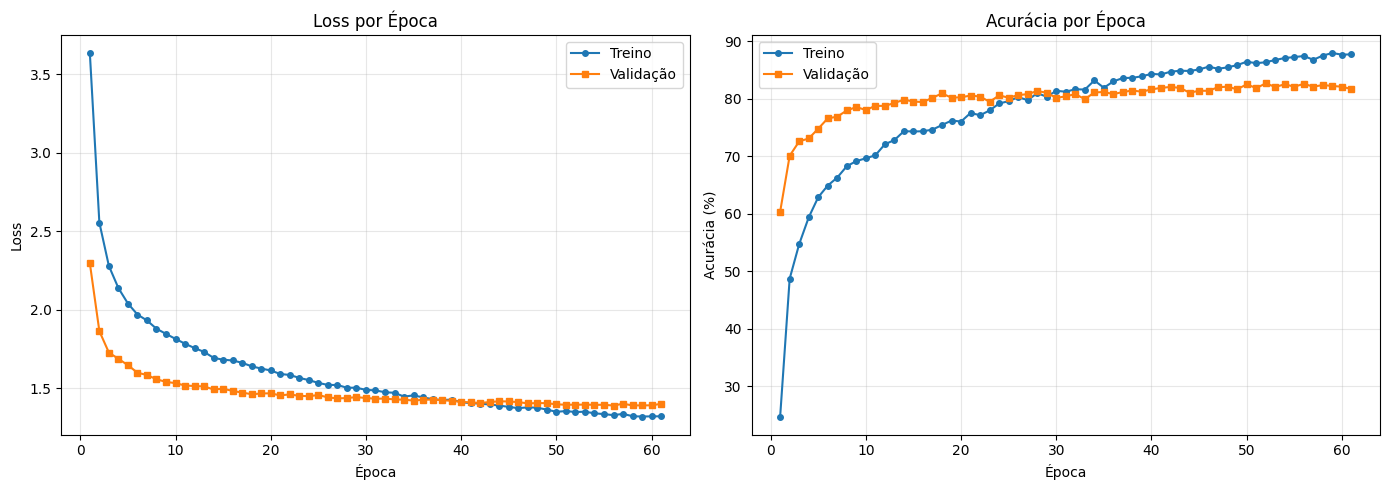

In [35]:
df = pd.read_csv("historico_treinamento.csv")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(df["epoca"], df["train_loss"], label="Treino", marker="o", markersize=4)
axes[0].plot(df["epoca"], df["validate_loss"], label="Validação", marker="s", markersize=4)
axes[0].set_title("Loss por Época")
axes[0].set_xlabel("Época")
axes[0].set_ylabel("Loss")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(df["epoca"], df["train_acuracia"], label="Treino", marker="o", markersize=4)
axes[1].plot(df["epoca"], df["validate_acuracia"], label="Validação", marker="s", markersize=4)
axes[1].set_title("Acurácia por Época")
axes[1].set_xlabel("Época")
axes[1].set_ylabel("Acurácia (%)")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("graficos_treinamento.png", dpi=150, bbox_inches="tight")
plt.show()

## Métricas no Conjunto de Teste

In [36]:
modelo.load_state_dict(torch.load('./data/efficientnetb0_dogs_best.pth', map_location=device))
modelo.eval()

todas_predicoes = []
todos_labels = []

with torch.no_grad():
  for images, labels in DataLoaderTeste:
    images = images.to(device)
    labels = labels.to(device)

    outputs = modelo(images)
    _, preds = torch.max(outputs, 1)

    todas_predicoes.extend(preds.cpu().numpy())
    todos_labels.extend(labels.cpu().numpy())

todas_predicoes = np.array(todas_predicoes)
todos_labels = np.array(todos_labels)

In [37]:
acc = accuracy_score(todos_labels, todas_predicoes)
prec = precision_score(todos_labels, todas_predicoes, average='macro', zero_division=0)
rec = recall_score(todos_labels, todas_predicoes, average='macro', zero_division=0)
f1 = f1_score(todos_labels, todas_predicoes, average='macro', zero_division=0)

tabela = PrettyTable()
tabela.title = "Métricas no Conjunto de Teste"
tabela.field_names = ["Métrica", "Valor"]
tabela.align["Métrica"] = "l"
tabela.align["Valor"] = "r"
tabela.add_row(["Acurácia", f"{acc:.4f} ({acc*100:.2f}%)"])
tabela.add_row(["Precision (macro)", f"{prec:.4f}"])
tabela.add_row(["Recall (macro)", f"{rec:.4f}"])
tabela.add_row(["F1-Score (macro)", f"{f1:.4f}"])
print(tabela)

+-------------------------------------+
|    Métricas no Conjunto de Teste    |
+-------------------+-----------------+
| Métrica           |           Valor |
+-------------------+-----------------+
| Acurácia          | 0.8248 (82.48%) |
| Precision (macro) |          0.8193 |
| Recall (macro)    |          0.8191 |
| F1-Score (macro)  |          0.8161 |
+-------------------+-----------------+


In [38]:
nomes_classes = handler_teste.classes

report = classification_report(
    todos_labels,
    todas_predicoes,
    target_names=nomes_classes,
    zero_division=0,
    output_dict=True
)

tabela_classes = PrettyTable()
tabela_classes.title = "Métricas por Classe"
tabela_classes.field_names = ["Classe", "Precision", "Recall", "F1-Score", "Support"]
tabela_classes.align["Classe"] = "l"
tabela_classes.align["Precision"] = "r"
tabela_classes.align["Recall"] = "r"
tabela_classes.align["F1-Score"] = "r"
tabela_classes.align["Support"] = "r"

for classe in nomes_classes:
    m = report[classe]
    tabela_classes.add_row([
        classe,
        f"{m['precision']:.4f}",
        f"{m['recall']:.4f}",
        f"{m['f1-score']:.4f}",
        int(m['support'])
    ])

tabela_classes.add_row(["---", "---", "---", "---", "---"])

for avg in ["macro avg", "weighted avg"]:
    m = report[avg]
    tabela_classes.add_row([
        avg,
        f"{m['precision']:.4f}",
        f"{m['recall']:.4f}",
        f"{m['f1-score']:.4f}",
        int(m['support'])
    ])

print(tabela_classes)

+--------------------------------------------------------------------------+
|                           Métricas por Classe                            |
+--------------------------------+-----------+--------+----------+---------+
| Classe                         | Precision | Recall | F1-Score | Support |
+--------------------------------+-----------+--------+----------+---------+
| Afghan_hound                   |    0.9778 | 0.9496 |   0.9635 |     139 |
| African_hunting_dog            |    0.9710 | 0.9710 |   0.9710 |      69 |
| Airedale                       |    0.8496 | 0.9412 |   0.8930 |     102 |
| American_Staffordshire_terrier |    0.5821 | 0.6094 |   0.5954 |      64 |
| Appenzeller                    |    0.5510 | 0.5294 |   0.5400 |      51 |
| Australian_terrier             |    0.7238 | 0.7917 |   0.7562 |      96 |
| Bedlington_terrier             |    0.9474 | 0.8780 |   0.9114 |      82 |
| Bernese_mountain_dog           |    0.9322 | 0.9322 |   0.9322 |     118 |

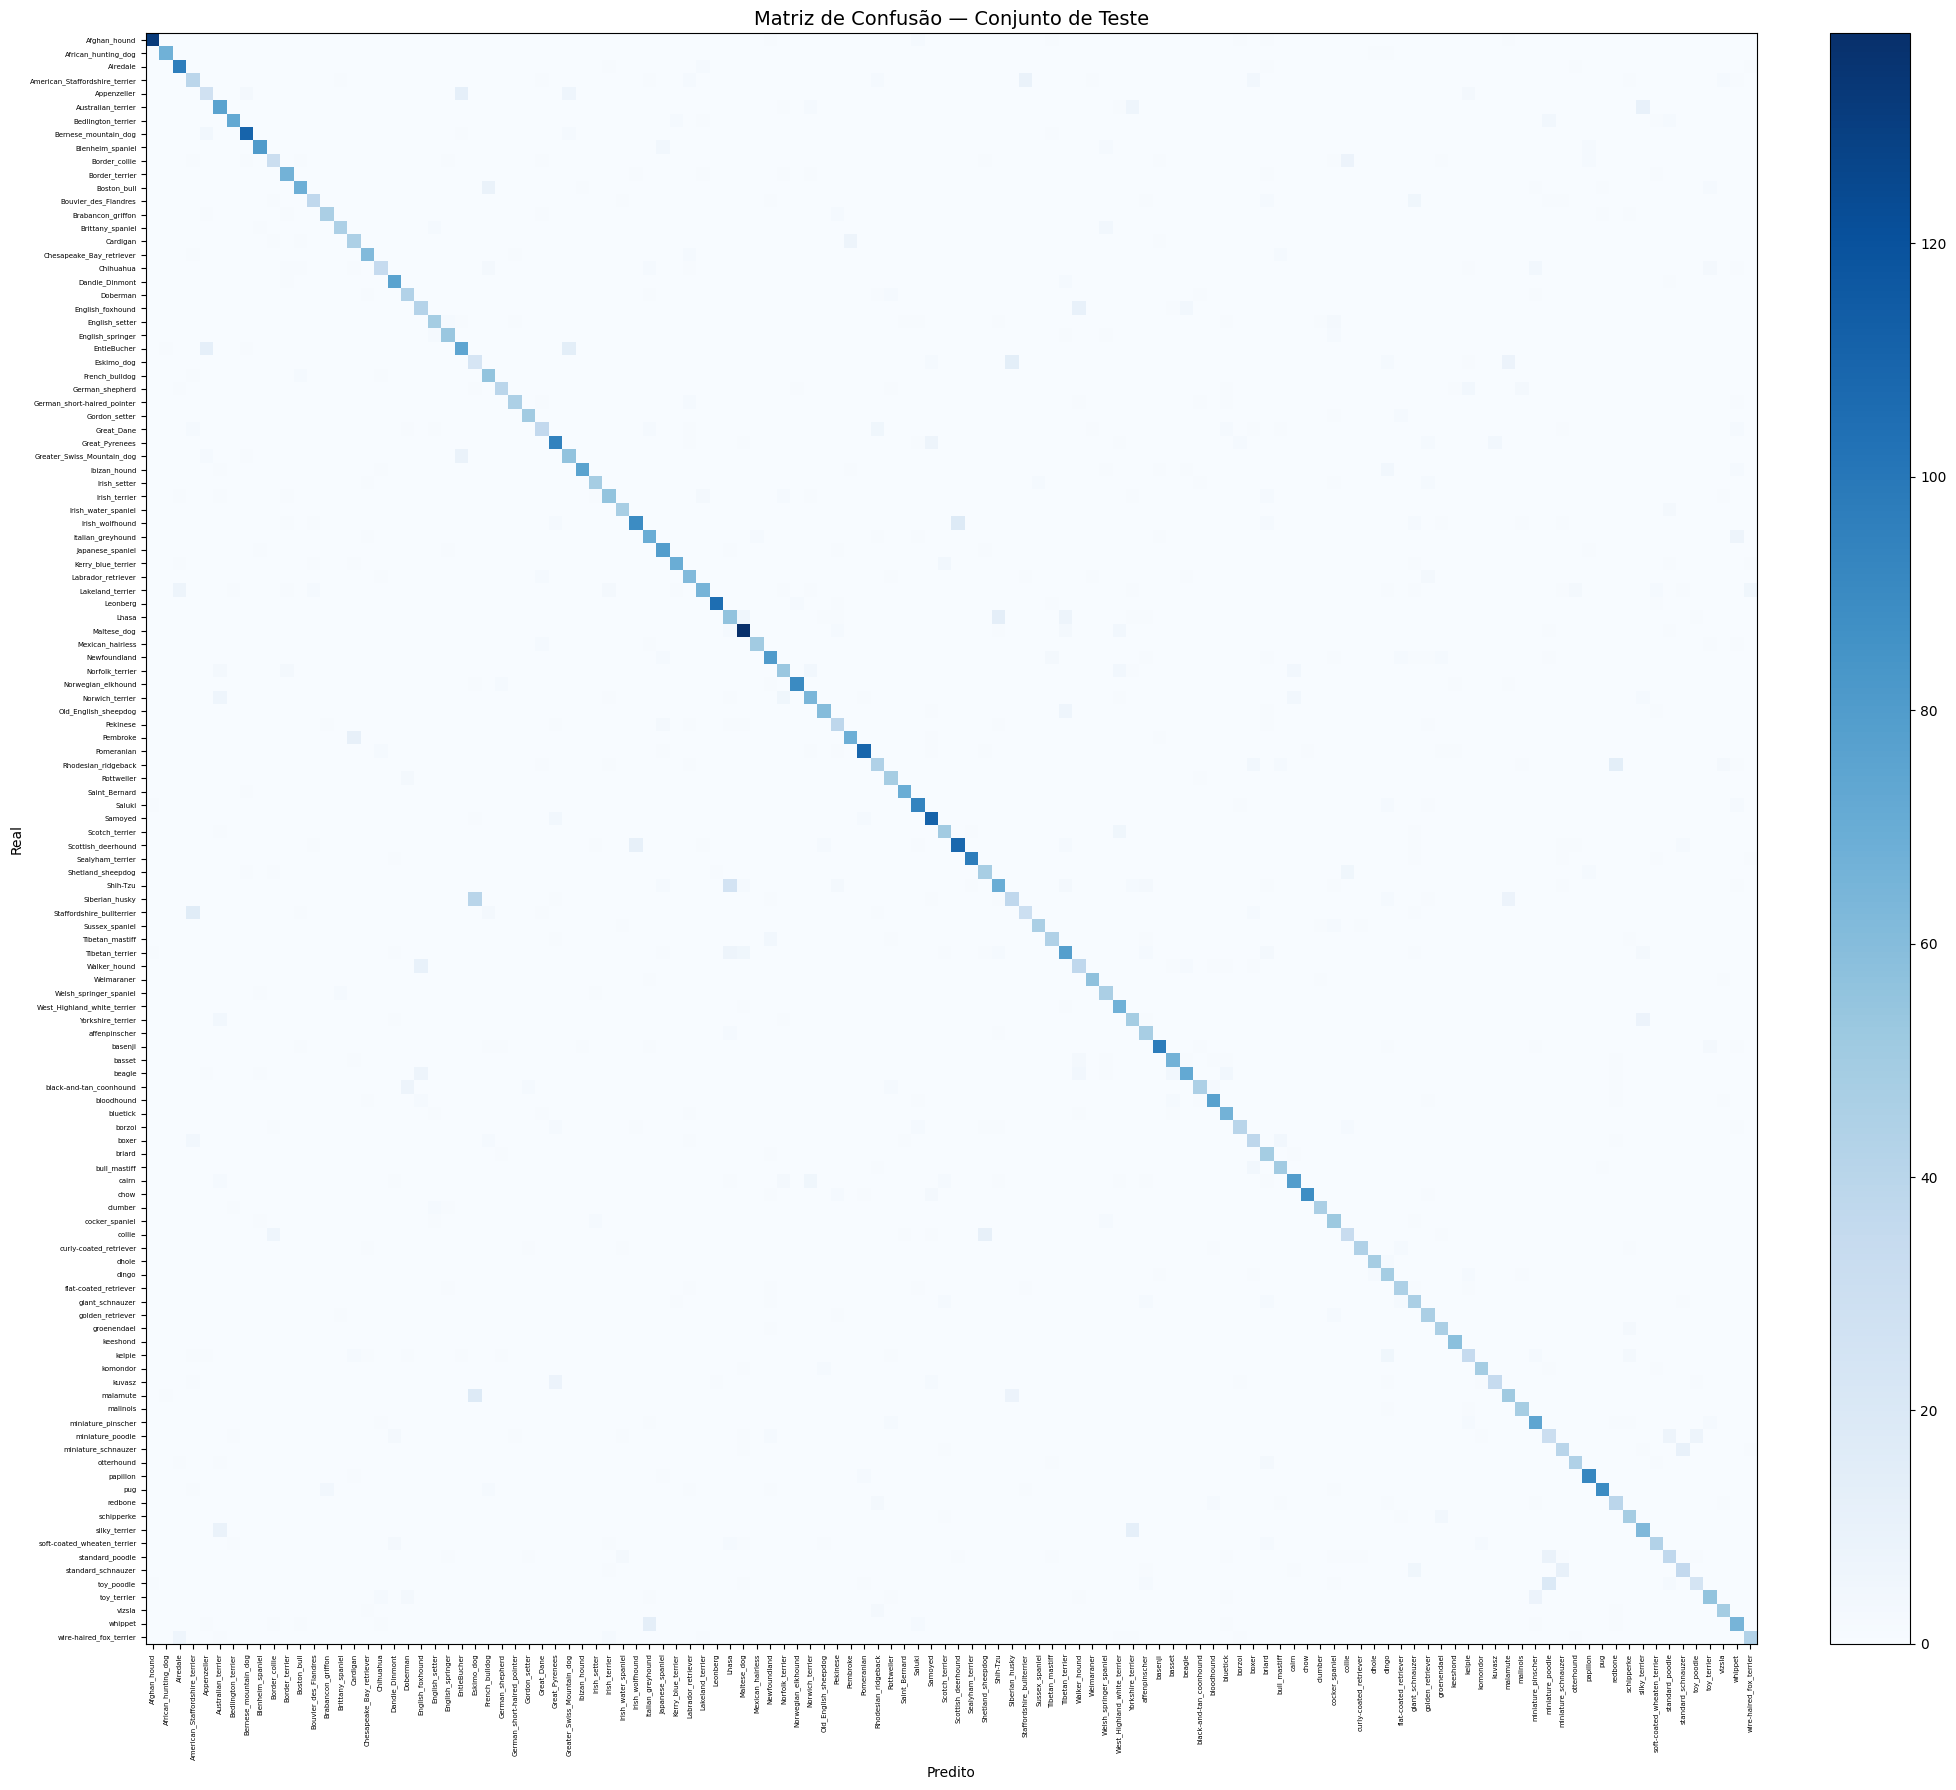

In [39]:
cm = confusion_matrix(todos_labels, todas_predicoes)

fig, ax = plt.subplots(figsize=(20, 18))
ax.imshow(cm, cmap="Blues", interpolation="nearest")
ax.set_xticks(range(len(nomes_classes)))
ax.set_yticks(range(len(nomes_classes)))
ax.set_xticklabels(nomes_classes, rotation=90, fontsize=5)
ax.set_yticklabels(nomes_classes, fontsize=5)
ax.set_xlabel("Predito")
ax.set_ylabel("Real")
ax.set_title("Matriz de Confusão — Conjunto de Teste", fontsize=14)
plt.colorbar(ax.images[0], ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.savefig("matriz_confusao.png", dpi=150, bbox_inches="tight")
plt.show()